In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import mmread
import warnings
warnings.filterwarnings('ignore')

out_dir = '/data1/project/yeonu/065_multi_rna/Deg_80/results_output'
data_dir = '/data1/project/yeonu/065_multi_rna/data'

In [2]:
# DEG 결과 로드 및 Top 10 Up + Top 10 Down 유전자 선택
deg = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Cirrhosis_NTvsTC_Hepatocyte.csv'))
deg_sig = deg[(deg['padj'] < 0.05) & (deg['log2FC'].abs() >= 0.5)].copy()

top_up = deg_sig[deg_sig['log2FC'] > 0].nsmallest(10, 'pvalue')
top_down = deg_sig[deg_sig['log2FC'] < 0].nsmallest(10, 'pvalue')

print(f'Significant DEGs (padj<0.05, |log2FC|>=0.5): {len(deg_sig)}')
print(f'Top 10 Up-regulated genes: {list(top_up["gene"])}')
print(f'Top 10 Down-regulated genes: {list(top_down["gene"])}')

Significant DEGs (padj<0.05, |log2FC|>=0.5): 861
Top 10 Up-regulated genes: ['GLUL', 'PDK4', 'DCXR', 'PAGE4', 'FTH1', 'GAPDH', 'ATOX1', 'UQCRQ', 'RPL10', 'ROBO1']
Top 10 Down-regulated genes: ['APOA1', 'A2M', 'SLC7A2', 'SORL1', 'DPYD', 'UTY', 'GPC6', 'ST6GAL1', 'LPIN2', 'CP']


In [3]:
# Count matrix & metadata 로드
print('Loading count matrix...')
counts = mmread(os.path.join(data_dir, 'counts_sparse_80.mtx')).tocsc()
gene_meta = pd.read_csv(os.path.join(data_dir, 'gene_metadata_80.csv'))
cell_meta = pd.read_csv(os.path.join(data_dir, 'cell_metadata.csv'), low_memory=False)

gene_names = list(gene_meta['gene'])
print(f'Matrix shape: {counts.shape}')
print(f'Genes: {len(gene_names)}, Cells: {len(cell_meta)}')

Loading count matrix...
Matrix shape: (99541, 1341)
Genes: 1341, Cells: 99541


In [4]:
# Cirrhosis Hepatocyte만 추출 (NT vs TC)
mask = (cell_meta['status'] == 'Cirrhosis') & (cell_meta['predicted_celltype'] == 'Hepatocytes')
mask = mask & (cell_meta['group'].isin(['NT', 'TC']))
cell_idx = np.where(mask.values)[0]
groups = cell_meta.loc[mask, 'group'].values

print(f'Cirrhosis Hepatocytes: {len(cell_idx)}')
print(f'  NT: {(groups == "NT").sum()}, TC: {(groups == "TC").sum()}')

Cirrhosis Hepatocytes: 55682
  NT: 8167, TC: 47515


In [5]:
# 20개 유전자 발현량 추출 + log1p 정규화
target_genes = list(top_up['gene']) + list(top_down['gene'])
gene_indices = [gene_names.index(g) for g in target_genes]

expr_raw = counts[cell_idx][:, gene_indices].toarray()
expr_log = np.log1p(expr_raw)

expr_df = pd.DataFrame(expr_log, columns=target_genes)
expr_df['group'] = groups

print(f'Expression matrix: {expr_df.shape}')
expr_df.head()

Expression matrix: (55682, 21)


,GLUL,PDK4,DCXR,PAGE4,FTH1,GAPDH,ATOX1,UQCRQ,RPL10,ROBO1,...,A2M,SLC7A2,SORL1,DPYD,UTY,GPC6,ST6GAL1,LPIN2,CP,group
0,1.598332,0.0,0.0,0.0,0.886693,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.886693,0.000000,0.886693,0.000000,0.000000,0.000000,0.886693,TC
1,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,TC
2,1.353851,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.902942,0.000000,0.000000,0.683726,0.000000,TC
3,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.000000,1.523246,0.000000,0.000000,0.000000,0.000000,0.000000,TC
4,1.520039,0.0,0.0,0.0,0.000000,0.0,0.832007,0.0,0.0,0.0,...,0.0,0.832007,0.000000,0.000000,0.000000,0.832007,0.832007,0.832007,0.000000,TC


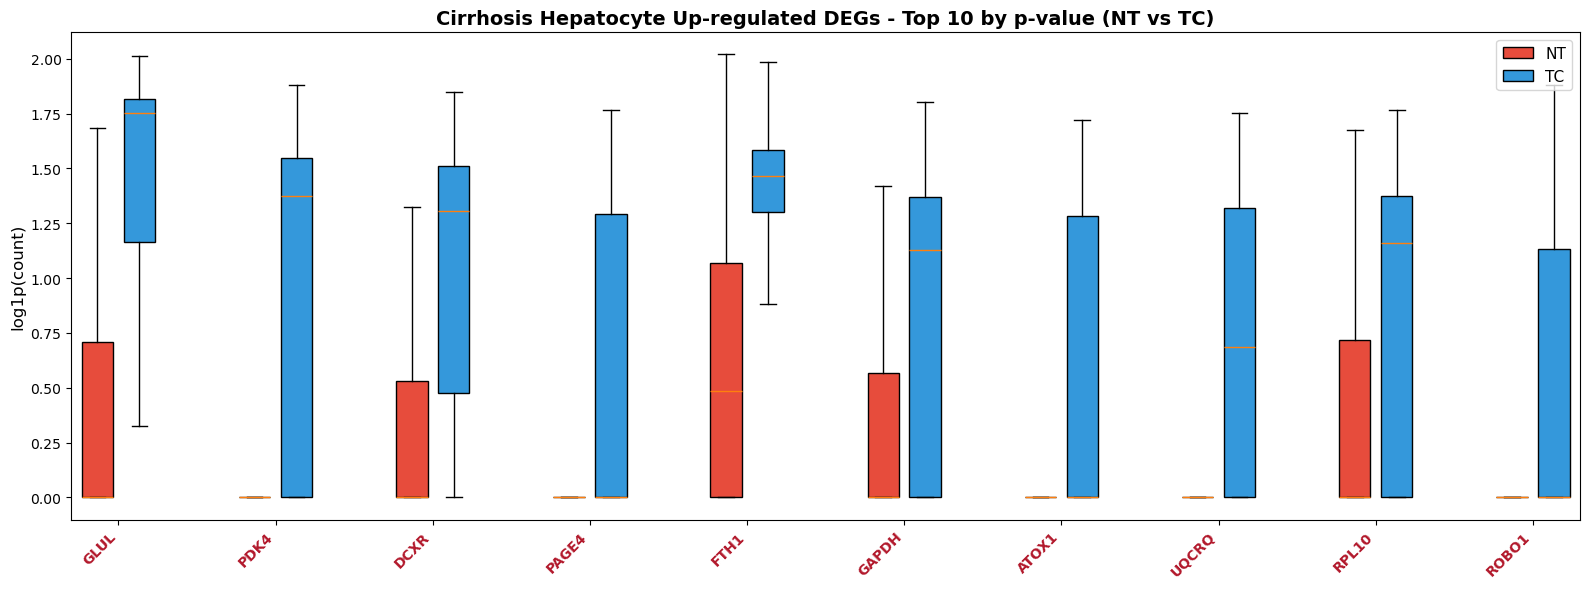

In [6]:
# Cirrhosis Boxplot: Up-regulated Top 10
up_genes = list(top_up['gene'])

fig, ax = plt.subplots(figsize=(16, 6))

nt_data = [expr_df.loc[expr_df['group'] == 'NT', g] for g in up_genes]
tc_data = [expr_df.loc[expr_df['group'] == 'TC', g] for g in up_genes]

pos_nt = np.arange(len(up_genes)) * 3
pos_tc = pos_nt + 0.8

bp_nt = ax.boxplot(nt_data, positions=pos_nt, widths=0.6, patch_artist=True, showfliers=False)
bp_tc = ax.boxplot(tc_data, positions=pos_tc, widths=0.6, patch_artist=True, showfliers=False)

for box in bp_nt['boxes']:
    box.set_facecolor('#E74C3C')
for box in bp_tc['boxes']:
    box.set_facecolor('#3498DB')

ax.set_xticks((pos_nt + pos_tc) / 2)
ax.set_xticklabels(up_genes, rotation=45, ha='right', fontsize=10, fontweight='bold')
for label in ax.get_xticklabels():
    label.set_color('#B2182B')

ax.set_ylabel('log1p(count)', fontsize=12)
ax.set_title('Cirrhosis Hepatocyte Up-regulated DEGs - Top 10 by p-value (NT vs TC)', fontsize=14, fontweight='bold')
ax.legend([bp_nt['boxes'][0], bp_tc['boxes'][0]], ['NT', 'TC'], loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'boxplot_Cirrhosis_Hepatocyte_Up.png'), dpi=300)
plt.show()

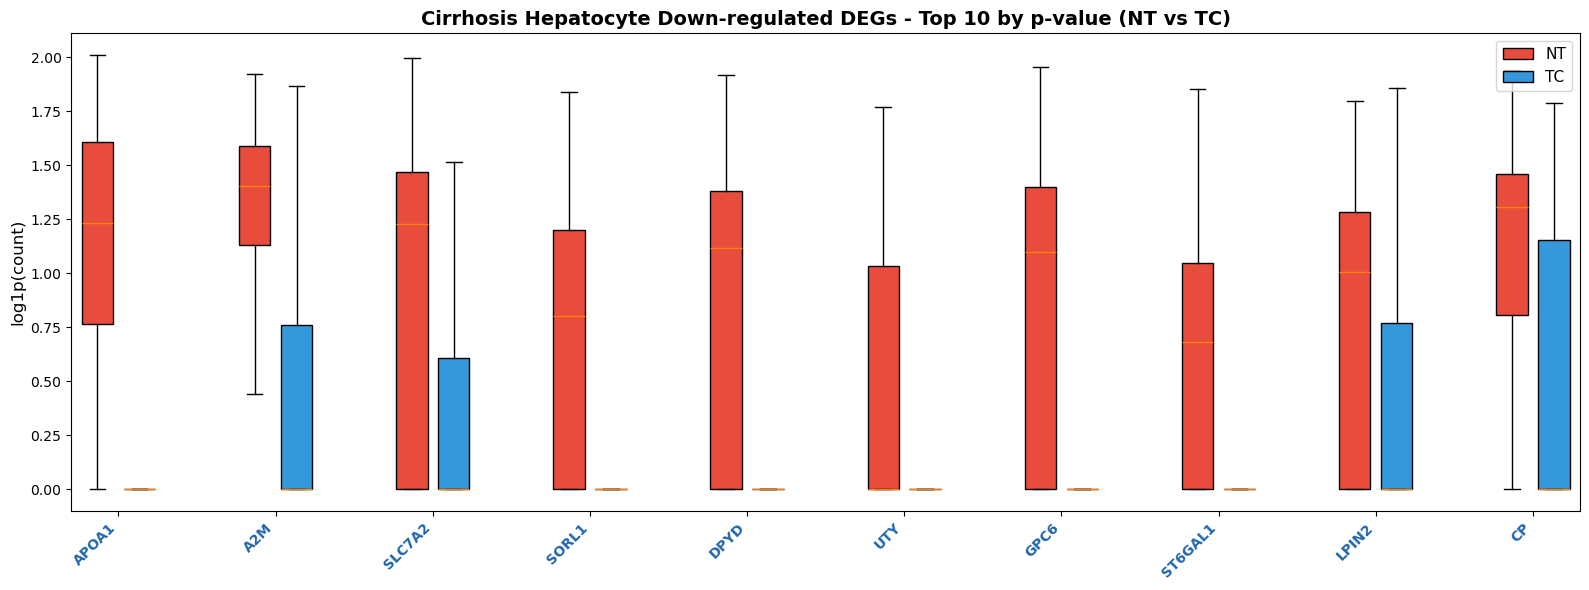

In [7]:
# Cirrhosis Boxplot: Down-regulated Top 10
down_genes = list(top_down['gene'])

fig, ax = plt.subplots(figsize=(16, 6))

nt_data = [expr_df.loc[expr_df['group'] == 'NT', g] for g in down_genes]
tc_data = [expr_df.loc[expr_df['group'] == 'TC', g] for g in down_genes]

pos_nt = np.arange(len(down_genes)) * 3
pos_tc = pos_nt + 0.8

bp_nt = ax.boxplot(nt_data, positions=pos_nt, widths=0.6, patch_artist=True, showfliers=False)
bp_tc = ax.boxplot(tc_data, positions=pos_tc, widths=0.6, patch_artist=True, showfliers=False)

for box in bp_nt['boxes']:
    box.set_facecolor('#E74C3C')
for box in bp_tc['boxes']:
    box.set_facecolor('#3498DB')

ax.set_xticks((pos_nt + pos_tc) / 2)
ax.set_xticklabels(down_genes, rotation=45, ha='right', fontsize=10, fontweight='bold')
for label in ax.get_xticklabels():
    label.set_color('#2166AC')

ax.set_ylabel('log1p(count)', fontsize=12)
ax.set_title('Cirrhosis Hepatocyte Down-regulated DEGs - Top 10 by p-value (NT vs TC)', fontsize=14, fontweight='bold')
ax.legend([bp_nt['boxes'][0], bp_tc['boxes'][0]], ['NT', 'TC'], loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'boxplot_Cirrhosis_Hepatocyte_Down.png'), dpi=300)
plt.show()

In [8]:
# Hepatitis DEG 결과 로드
deg_h = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Hepatitis_NTvsTC_Hepatocyte.csv'))
deg_h_sig = deg_h[(deg_h['padj'] < 0.05) & (deg_h['log2FC'].abs() >= 0.5)].copy()

top_up_h = deg_h_sig[deg_h_sig['log2FC'] > 0].nsmallest(10, 'pvalue')
top_down_h = deg_h_sig[deg_h_sig['log2FC'] < 0].nsmallest(10, 'pvalue')

print(f'Significant DEGs (padj<0.05, |log2FC|>=0.5): {len(deg_h_sig)}')
print(f'Top 10 Up-regulated genes: {list(top_up_h["gene"])}')
print(f'Top 10 Down-regulated genes: {list(top_down_h["gene"])}')

Significant DEGs (padj<0.05, |log2FC|>=0.5): 313
Top 10 Up-regulated genes: ['APOA2', 'APOC1', 'APOC3', 'ALB', 'TTR', 'FTL', 'RBP4', 'APOA1', 'APOC2', 'AMBP']
Top 10 Down-regulated genes: ['MALAT1', 'B2M', 'HLA-B', 'HLA-A', 'TXNIP', 'HLA-C', 'MTRNR2L12', 'HLA-E', 'TMSB4X', 'RPL13A']


In [9]:
# Hepatitis Hepatocyte 세포 추출 (NT vs TC)
mask_h = (cell_meta['status'] == 'Hepatitis') & (cell_meta['predicted_celltype'] == 'Hepatocytes')
mask_h = mask_h & (cell_meta['group'].isin(['NT', 'TC']))
cell_idx_h = np.where(mask_h.values)[0]
groups_h = cell_meta.loc[mask_h, 'group'].values

# 20개 유전자 발현량 추출
target_genes_h = list(top_up_h['gene']) + list(top_down_h['gene'])
gene_indices_h = [gene_names.index(g) for g in target_genes_h]

expr_raw_h = counts[cell_idx_h][:, gene_indices_h].toarray()
expr_log_h = np.log1p(expr_raw_h)

expr_df_h = pd.DataFrame(expr_log_h, columns=target_genes_h)
expr_df_h['group'] = groups_h

print(f'Hepatitis Hepatocytes: {len(cell_idx_h)} (NT: {(groups_h=="NT").sum()}, TC: {(groups_h=="TC").sum()})')
print(f'Expression matrix: {expr_df_h.shape}')

Hepatitis Hepatocytes: 2874 (NT: 315, TC: 2559)
Expression matrix: (2874, 21)


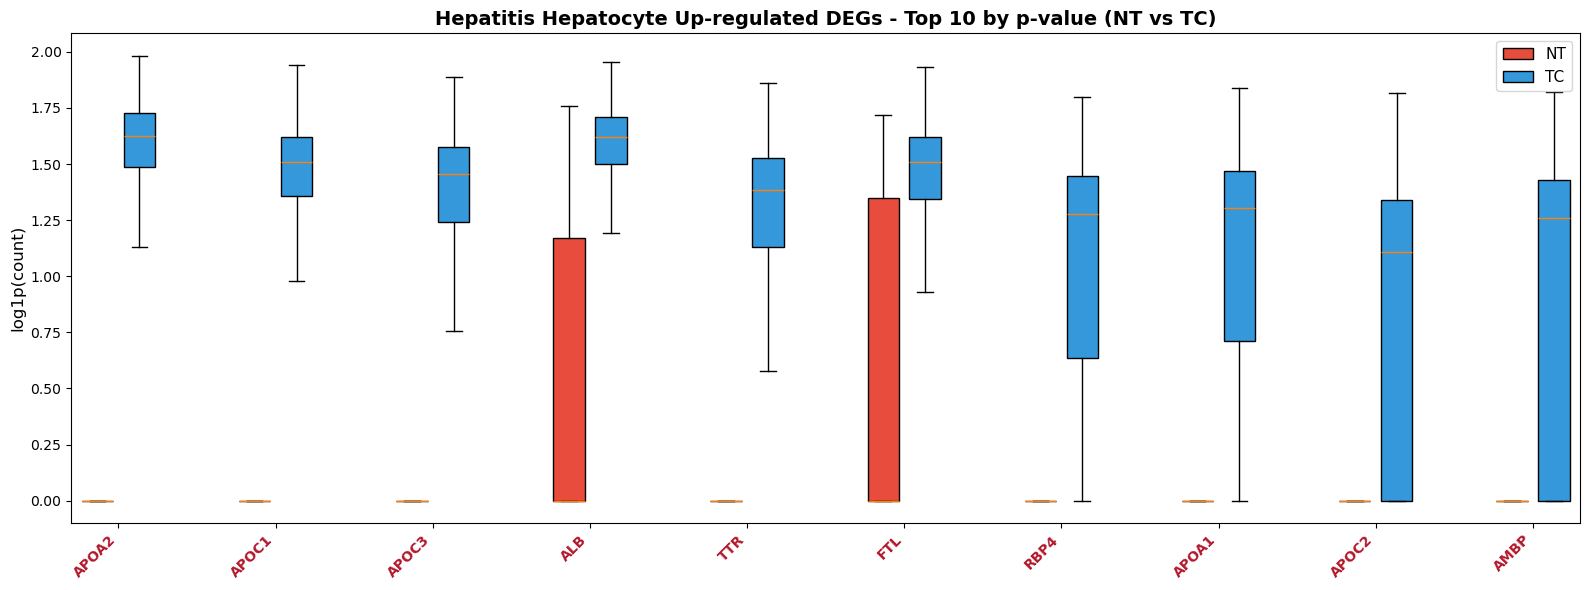

In [10]:
# Hepatitis Boxplot: Up-regulated Top 10
up_genes_h = list(top_up_h['gene'])

fig, ax = plt.subplots(figsize=(16, 6))

nt_data = [expr_df_h.loc[expr_df_h['group'] == 'NT', g] for g in up_genes_h]
tc_data = [expr_df_h.loc[expr_df_h['group'] == 'TC', g] for g in up_genes_h]

pos_nt = np.arange(len(up_genes_h)) * 3
pos_tc = pos_nt + 0.8

bp_nt = ax.boxplot(nt_data, positions=pos_nt, widths=0.6, patch_artist=True, showfliers=False)
bp_tc = ax.boxplot(tc_data, positions=pos_tc, widths=0.6, patch_artist=True, showfliers=False)

for box in bp_nt['boxes']:
    box.set_facecolor('#E74C3C')
for box in bp_tc['boxes']:
    box.set_facecolor('#3498DB')

ax.set_xticks((pos_nt + pos_tc) / 2)
ax.set_xticklabels(up_genes_h, rotation=45, ha='right', fontsize=10, fontweight='bold')
for label in ax.get_xticklabels():
    label.set_color('#B2182B')

ax.set_ylabel('log1p(count)', fontsize=12)
ax.set_title('Hepatitis Hepatocyte Up-regulated DEGs - Top 10 by p-value (NT vs TC)', fontsize=14, fontweight='bold')
ax.legend([bp_nt['boxes'][0], bp_tc['boxes'][0]], ['NT', 'TC'], loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'boxplot_Hepatitis_Hepatocyte_Up.png'), dpi=300)
plt.show()

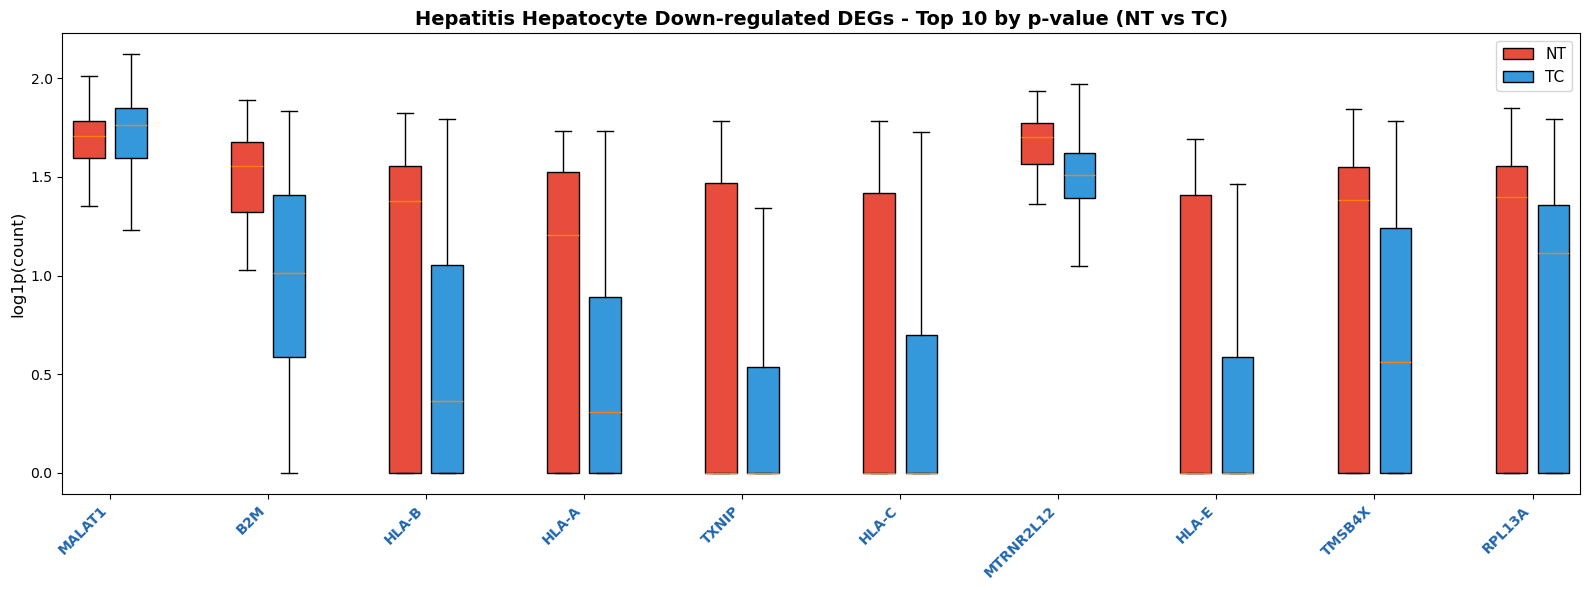

In [11]:
# Hepatitis Boxplot: Down-regulated Top 10
down_genes_h = list(top_down_h['gene'])

fig, ax = plt.subplots(figsize=(16, 6))

nt_data = [expr_df_h.loc[expr_df_h['group'] == 'NT', g] for g in down_genes_h]
tc_data = [expr_df_h.loc[expr_df_h['group'] == 'TC', g] for g in down_genes_h]

pos_nt = np.arange(len(down_genes_h)) * 3
pos_tc = pos_nt + 0.8

bp_nt = ax.boxplot(nt_data, positions=pos_nt, widths=0.6, patch_artist=True, showfliers=False)
bp_tc = ax.boxplot(tc_data, positions=pos_tc, widths=0.6, patch_artist=True, showfliers=False)

for box in bp_nt['boxes']:
    box.set_facecolor('#E74C3C')
for box in bp_tc['boxes']:
    box.set_facecolor('#3498DB')

ax.set_xticks((pos_nt + pos_tc) / 2)
ax.set_xticklabels(down_genes_h, rotation=45, ha='right', fontsize=10, fontweight='bold')
for label in ax.get_xticklabels():
    label.set_color('#2166AC')

ax.set_ylabel('log1p(count)', fontsize=12)
ax.set_title('Hepatitis Hepatocyte Down-regulated DEGs - Top 10 by p-value (NT vs TC)', fontsize=14, fontweight='bold')
ax.legend([bp_nt['boxes'][0], bp_tc['boxes'][0]], ['NT', 'TC'], loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'boxplot_Hepatitis_Hepatocyte_Down.png'), dpi=300)
plt.show()